In [10]:
import sys
from pathlib import Path

BASE_PATH = Path(".").resolve()
sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
from models import GraphSAGEModel, GraphSAGE

MODELS_DIR = BASE_PATH / "gSAGE" / "extrapolation" / "models" / "revised_training"
model_name = "b3_balanced"
model_path = MODELS_DIR / f"{model_name}.pt"
print(f"Models dir: {MODELS_DIR}")
print(f"Model path: {model_path}")

Models dir: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/models/revised_training
Model path: /Users/billxu/quantum-error-correction/code/gSAGE/extrapolation/models/revised_training/b3_balanced.pt


In [11]:
save_dict = torch.load(model_path, map_location="cpu", weights_only=False)
config = save_dict["config"]
split_name = save_dict.get("split_name", model_name)

# Layer sizes for diagram: input -> num_layers x hidden -> 64 -> 1
layer_sizes = (
    [config["in_channels"]]
    + [config["hidden_dim"]] * config["num_layers"]
    + [64, 1]
)

# Optional: instantiate model and load weights for later use
device = torch.device("cpu")
model = GraphSAGEModel(
    in_channels=config["in_channels"],
    hidden_dim=config["hidden_dim"],
    num_layers=config["num_layers"],
    dropout=config.get("dropout", 0.0),
    aggr=config.get("aggr", "mean"),
).to(device)
model.load_state_dict(save_dict["state_dict"])
model.eval()

print(f"Model: {split_name}")
print(f"Config: {config}")
print(f"Layer sizes: {' → '.join(map(str, layer_sizes))}")

Model: b3_balanced
Config: {'in_channels': 5, 'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.0, 'aggr': 'max', 'seed': 42}
Layer sizes: 5 → 128 → 128 → 128 → 128 → 128 → 64 → 1


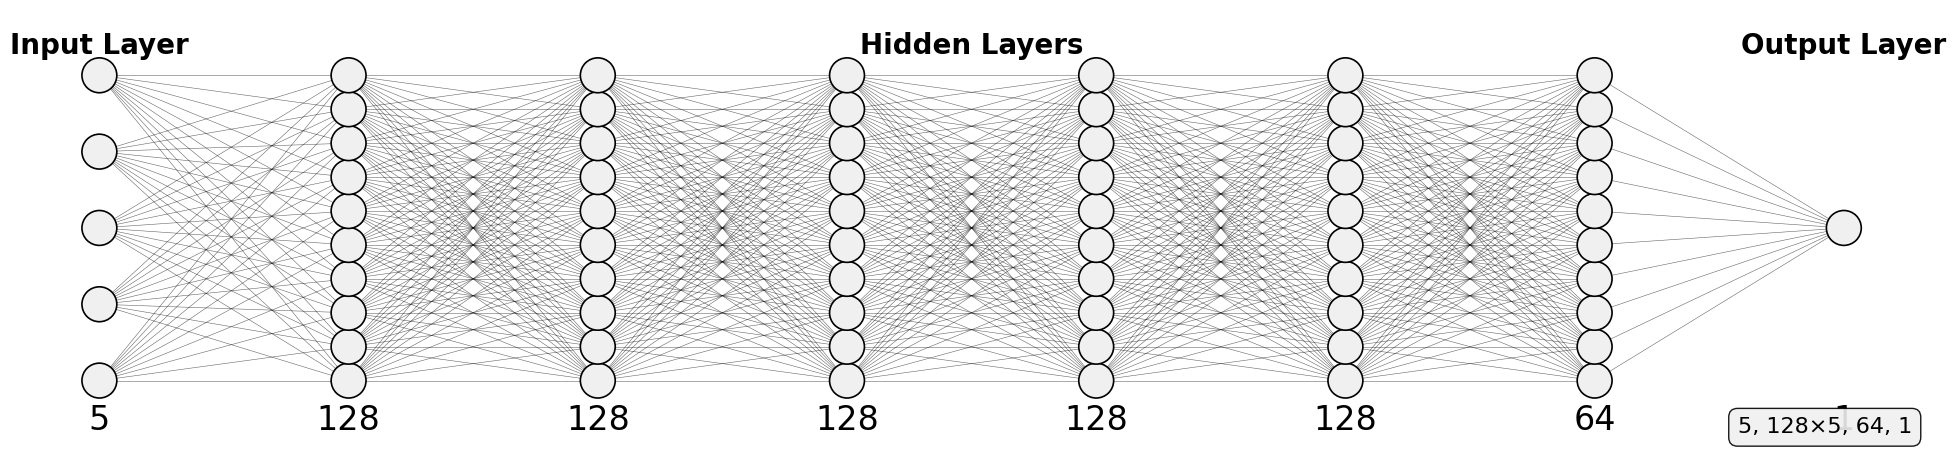

In [16]:
def draw_neural_network(layer_sizes, split_name, config=None, max_display=10):
    """Draw feedforward-style diagram: columns of circles, black style, with layer labels."""
    n_layers = len(layer_sizes)
    # Display count per layer (cap for readability)
    display_counts = [min(s, max_display) for s in layer_sizes]
    # X position for each layer column (0–4 so aspect equal gives 4:1 width:height)
    x_positions = np.linspace(0, 4, n_layers)
    # Vertical extent for nodes (same for all columns)
    y_lo, y_hi = 0.15, 0.85

    # Wider aspect ~1:4; equal aspect keeps circles round
    fig, ax = plt.subplots(1, 1, figsize=(20, 5))
    ax.set_xlim(-0.2, 4.2)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")

    # Black color scheme
    node_face = "#f0f0f0"
    node_edge = "#000000"
    line_color = "#000000"
    text_color = "#000000"

    node_positions = []  # list of (x, y) arrays per layer
    for i, (size, n_show) in enumerate(zip(layer_sizes, display_counts)):
        x = x_positions[i]
        if n_show <= 1:
            ys = np.array([0.5])
        else:
            ys = np.linspace(y_lo, y_hi, n_show)
        node_positions.append((np.full_like(ys, x), ys))

    # Draw connections between adjacent layers (thin black lines)
    for i in range(n_layers - 1):
        xs_src, ys_src = node_positions[i]
        xs_dst, ys_dst = node_positions[i + 1]
        for xa, ya in zip(xs_src, ys_src):
            for xb, yb in zip(xs_dst, ys_dst):
                ax.plot([xa, xb], [ya, yb], color=line_color, lw=0.4, alpha=0.6, zorder=0)

    # Draw nodes (circles)
    for i in range(n_layers):
        xs, ys = node_positions[i]
        for x, y in zip(xs, ys):
            circle = plt.Circle((x, y), 0.04, facecolor=node_face, edgecolor=node_edge, linewidth=1.2, zorder=1)
            ax.add_patch(circle)

    # Layer labels above columns (Input, Hidden centered over middle, Output)
    for i in range(n_layers):
        x = x_positions[i]
        if i == 0:
            ax.text(x, 0.95, "Input Layer", ha="center", va="top", fontsize=20, color=text_color, fontweight="bold")
        elif i == n_layers - 1:
            ax.text(x, 0.95, "Output Layer", ha="center", va="top", fontsize=20, color=text_color, fontweight="bold")
    # Hidden Layers label centered over the middle of all hidden columns
    if n_layers > 2:
        mid_hidden_x = (x_positions[1] + x_positions[n_layers - 2]) / 2
        ax.text(mid_hidden_x, 0.95, "Hidden Layers", ha="center", va="top", fontsize=20, color=text_color, fontweight="bold")

    # Dimension labels below each column (true size)
    for i, size in enumerate(layer_sizes):
        ax.text(x_positions[i], 0.02, str(size), ha="center", va="bottom", fontsize=24, color=text_color)

    # Summary label at bottom right (no GraphSAGE title, no arrows in summary)
    if config and config.get("num_layers", 0) > 1:
        summary = f"5, {config['hidden_dim']}×{config['num_layers']}, 64, 1"
    else:
        summary = ", ".join(map(str, layer_sizes))
    props = dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor=node_edge, alpha=0.9)
    ax.text(0.99, 0.02, summary, transform=ax.transAxes, fontsize=16, va="bottom", ha="right",
            bbox=props, color=text_color)

    plt.tight_layout()
    plt.show()


draw_neural_network(layer_sizes, split_name, config=config)